# Animal Multi-Day Behavior Workflow

This notebook collects behavioral sessions for a single animal, converts Unity JSON logs to HDF5 files, and assembles multi-day trial summaries with rolling accuracy metrics. Adjust the parameters below and run the notebook top-to-bottom.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "behavioral_analysis").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate repository root starting from {start}"
    )


repo_root = find_repo_root(Path.cwd())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Repository root: {repo_root}")
print(f"Added to sys.path: {src_path}")

Repository root: /groups/spruston/home/moharb/DELTA_Behavior
Added to sys.path: /groups/spruston/home/moharb/DELTA_Behavior/src


In [2]:
# Parameters
ANIMAL_ID = "BM42"  # Update with the animal identifier of interest

# Known data roots (checked in order; first existing match is used)
_DATA_ROOTS = [
    Path("/groups/spruston/sprustonlab/mesoscope-data"),
    Path("/nearline/spruston/Boaz/Mesoscope"),
]
_matched = [r / ANIMAL_ID for r in _DATA_ROOTS if (r / ANIMAL_ID).exists()]
if not _matched:
    raise FileNotFoundError(
        f"Could not find data for {ANIMAL_ID} under any known root: {_DATA_ROOTS}"
    )
SEARCH_ROOT = _matched[0]
print(f"Using SEARCH_ROOT: {SEARCH_ROOT}")

OUTPUT_HDF5_DIR = repo_root / "outputs" / "hdf5" / ANIMAL_ID
ROLLING_WINDOW = 20  # Number of trials in the running accuracy window
OVERWRITE_EXISTING = False  # Set True to regenerate HDF5 files even if they exist
SKIP_FAILED_SESSIONS = True  # Continue when a JSON log is missing required events

Using SEARCH_ROOT: /groups/spruston/sprustonlab/mesoscope-data/BM42


In [3]:
import pandas as pd
from behavioral_analysis.analysis import collect_json_logs

json_paths = collect_json_logs(ANIMAL_ID, SEARCH_ROOT)
if not json_paths:
    raise FileNotFoundError(f"No JSON logs for {ANIMAL_ID} under {SEARCH_ROOT}")

json_summary = pd.DataFrame({
    "json_path": [path.as_posix() for path in json_paths]
})
json_summary

,json_path
0,/groups/spruston/sprustonlab/mesoscope-data/BM...
1,/groups/spruston/sprustonlab/mesoscope-data/BM...
2,/groups/spruston/sprustonlab/mesoscope-data/BM...
3,/groups/spruston/sprustonlab/mesoscope-data/BM...
4,/groups/spruston/sprustonlab/mesoscope-data/BM...
5,/groups/spruston/sprustonlab/mesoscope-data/BM...
6,/groups/spruston/sprustonlab/mesoscope-data/BM...
7,/groups/spruston/sprustonlab/mesoscope-data/BM...
8,/groups/spruston/sprustonlab/mesoscope-data/BM...
9,/groups/spruston/sprustonlab/mesoscope-data/BM...


In [4]:
from behavioral_analysis.analysis import convert_json_sessions

conversion_result = convert_json_sessions(
    json_paths,
    animal_id=ANIMAL_ID,
    output_dir=OUTPUT_HDF5_DIR,
    overwrite=OVERWRITE_EXISTING,
    verbose=True,
    skip_failures=SKIP_FAILED_SESSIONS,
    return_failures=True,
)

if isinstance(conversion_result, tuple):
    conversions, conversion_failures = conversion_result
else:  # Backward compatibility
    conversions = conversion_result
    conversion_failures = []

if not conversions:
    raise RuntimeError("No sessions were successfully converted; adjust SEARCH_ROOT or ensure logs contain cue data.")

conversion_summary = pd.DataFrame({
    "session_order": range(1, len(conversions) + 1),
    "session_label": [c.session_label for c in conversions],
    "session_date": [c.session_date for c in conversions],
    "session_number": [c.session_number for c in conversions],
    "json_path": [c.json_path.as_posix() for c in conversions],
    "hdf5_path": [c.hdf5_path.as_posix() for c in conversions],
}).sort_values("session_date").reset_index(drop=True)
conversion_summary

Processing JSON data with global position: /groups/spruston/sprustonlab/mesoscope-data/BM42/2026_05_08/1/Log BM42 2026-05-08 session 1.json
Step 1: Parsing JSON file
Parsing file: /groups/spruston/sprustonlab/mesoscope-data/BM42/2026_05_08/1/Log BM42 2026-05-08 session 1.json
File size: 29.66 MB
Processed 10000 events...
Processed 20000 events...
Processed 30000 events...
Processed 40000 events...
Processed 50000 events...
Processed 60000 events...
Processed 70000 events...
Processed 80000 events...
Processed 90000 events...
Processed 100000 events...
Processed 110000 events...
Processed 120000 events...
Processed 130000 events...
Processed 140000 events...
Processed 150000 events...
Processed 160000 events...
Processed 170000 events...
Processed 180000 events...
Processed 190000 events...
Processed 200000 events...
Processed 210000 events...
Processed 220000 events...
Processed 230000 events...
Processed 240000 events...
Processed 250000 events...
Processed 260000 events...
Processed 

/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['name', 'gain'], dtype='object')]

  store[f'events/{safe_event_type}'] = df


  Saved Position data (124465 rows)
  Saved Path Position data (124464 rows)
  Saved Log data (62024 rows)
  Saved Cue State data (334 rows)
  Saved Start Period data (1 rows)
  Saved Cue Result data (324 rows)
  Saved Reward data (164 rows)
  Saved Lick data (3627 rows)
  Saved Corridor_Info data (33 rows)
  Saved Lick_Position data (3627 rows)
  Saved Trials data (324 rows)
  Saved Lick_Cue_Window data (1971 rows)
  Saved metadata


/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  store['metadata'] = pd.Series(metadata)


Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM42/Log BM42 2026-05-08 session 1.h5 in 0.82 seconds
Processing completed in 8.75 seconds
Output file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM42/Log BM42 2026-05-08 session 1.h5
Processing JSON data with global position: /groups/spruston/sprustonlab/mesoscope-data/BM42/2026_05_11/1/Log BM42 2026-05-11 session 1.json
Step 1: Parsing JSON file
Parsing file: /groups/spruston/sprustonlab/mesoscope-data/BM42/2026_05_11/1/Log BM42 2026-05-11 session 1.json
File size: 46.05 MB
Processed 10000 events...
Processed 20000 events...
Processed 30000 events...
Processed 40000 events...
Processed 50000 events...
Processed 60000 events...
Processed 70000 events...
Processed 80000 events...
Processed 90000 events...
Processed 100000 events...
Processed 110000 events...
Processed 120000 events...
Processed 130000 events...
Processed 140000 events...
Processed 150000 events...
Processed 160000 eve

...

/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['name', 'gain'], dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  store['metadata'] = pd.Series(metadata)


  Saved Position data (72968 rows)
  Saved Path Position data (72967 rows)
  Saved Log data (96752 rows)
  Saved Cue State data (262 rows)
  Saved Start Period data (1 rows)
  Saved Lick data (3261 rows)
  Saved Reward data (106 rows)
  Saved Cue Result data (254 rows)
  Saved Corridor_Info data (32 rows)
  Saved Lick_Position data (3261 rows)
  Saved Trials data (254 rows)
  Saved Lick_Cue_Window data (2879 rows)
  Saved metadata
Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM42/Log BM42 2026-05-20 session 1.h5 in 0.26 seconds
Processing completed in 5.09 seconds
Output file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM42/Log BM42 2026-05-20 session 1.h5
Processing JSON data with global position: /groups/spruston/sprustonlab/mesoscope-data/BM42/2026_05_21/1/Log BM42 2026-05-21 session 1.json
Step 1: Parsing JSON file
Parsing file: /groups/spruston/sprustonlab/mesoscope-data/BM42/2026_05_21/1/Log BM42 2026-05-21 session 1.json
F

/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['name', 'gain'], dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->values] [items->None]

  store['metadata'] = pd.Series(metadata)


  Saved Position data (71361 rows)
  Saved Path Position data (71360 rows)
  Saved Log data (105784 rows)
  Saved Cue State data (273 rows)
  Saved Start Period data (1 rows)
  Saved Lick data (5129 rows)
  Saved Cue Result data (265 rows)
  Saved Reward data (127 rows)
  Saved Corridor_Info data (34 rows)
  Saved Lick_Position data (5129 rows)
  Saved Trials data (265 rows)
  Saved Lick_Cue_Window data (3861 rows)
  Saved metadata
Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM42/Log BM42 2026-05-21 session 1.h5 in 0.26 seconds
Processing completed in 5.12 seconds
Output file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/hdf5/BM42/Log BM42 2026-05-21 session 1.h5


,session_order,session_label,session_date,session_number,json_path,hdf5_path
0,1,2026-05-08 - Log BM42 2026-05-08 session 1,2026-05-08,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
1,2,2026-05-11 - Log BM42 2026-05-11 session 1,2026-05-11,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
2,3,2026-05-12 - Log BM42 2026-05-12 session 1,2026-05-12,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
3,4,2026-05-13 - Log BM42 2026-05-13 session 1,2026-05-13,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
4,5,2026-05-14 - Log BM42 2026-05-14 session 1,2026-05-14,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
5,6,2026-05-15 - Log BM42 2026-05-15 session 1,2026-05-15,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
6,7,2026-05-16 - Log BM42 2026-05-16 session 1,2026-05-16,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
7,8,2026-05-17 - Log BM42 2026-05-17 session 1,2026-05-17,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
8,9,2026-05-18 - Log BM42 2026-05-18 session 1,2026-05-18,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...
9,10,2026-05-19 - Log BM42 2026-05-19 session 1,2026-05-19,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...


In [5]:
if conversion_failures:
    failure_summary = pd.DataFrame([
        {"json_path": failure.json_path.as_posix(), "error": failure.error}
        for failure in conversion_failures
    ])
    display(failure_summary)
else:
    print("No conversion failures.")

No conversion failures.


In [6]:
from behavioral_analysis.analysis import prepare_multi_day_trials

multi_day = prepare_multi_day_trials(conversions, rolling_window=ROLLING_WINDOW)
multi_day.session_summary


,session_order,session_date,session_label,session_number,source_json,source_hdf5,n_trials,accuracy_pct,hit_rate_pct,fa_rate_pct
0,1,2026-05-08,2026-05-08 - Log BM42 2026-05-08 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,324,69.753086,99.393939,61.006289
1,2,2026-05-11,2026-05-11 - Log BM42 2026-05-11 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,210,83.333333,100.000000,33.653846
2,3,2026-05-12,2026-05-12 - Log BM42 2026-05-12 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,203,97.536946,95.535714,0.000000
3,4,2026-05-13,2026-05-13 - Log BM42 2026-05-13 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,305,99.016393,99.280576,1.204819
4,5,2026-05-14,2026-05-14 - Log BM42 2026-05-14 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,307,98.371336,98.051948,1.307190
5,6,2026-05-15,2026-05-15 - Log BM42 2026-05-15 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,240,98.750000,99.264706,1.923077
6,7,2026-05-16,2026-05-16 - Log BM42 2026-05-16 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,177,89.265537,100.000000,20.212766
7,8,2026-05-17,2026-05-17 - Log BM42 2026-05-17 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,195,94.358974,100.000000,11.000000
8,9,2026-05-18,2026-05-18 - Log BM42 2026-05-18 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,194,93.814433,99.009901,11.827957
9,10,2026-05-19,2026-05-19 - Log BM42 2026-05-19 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,269,66.542751,72.262774,39.393939


In [7]:
daily_accuracy = (
    multi_day.trials.groupby("session_date")
    ["correct"]
    .mean()
    .mul(100.0)
    .reset_index(name="accuracy_pct")
)
daily_accuracy

,session_date,accuracy_pct
0,2026-05-08,69.753086
1,2026-05-11,83.333333
2,2026-05-12,97.536946
3,2026-05-13,99.016393
4,2026-05-14,98.371336
5,2026-05-15,98.750000
6,2026-05-16,89.265537
7,2026-05-17,94.358974
8,2026-05-18,93.814433
9,2026-05-19,66.542751


In [8]:
multi_day.trials.head()

,trial_id,corridor,cue_id_in_corridor,cue_type,is_rewarding,cue_position,cue_position_cm,global_position_cm,cue_onset_ms,cue_outcome_ms,...,licks_in_window,trial_in_session,session_order,session_date,session_label,session_number,source_json,source_hdf5,trial_index_global,rolling_accuracy_pct
0,0,1,0,Non-rewarding,False,4159,41.59,41.59,10983.93,19787.69,...,0,1,1,2026-05-08,2026-05-08 - Log BM42 2026-05-08 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,1,100.0
1,1,1,1,Non-rewarding,False,9039,90.39,90.39,10984.65,23073.65,...,0,2,1,2026-05-08,2026-05-08 - Log BM42 2026-05-08 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,2,100.0
2,2,1,2,Rewarding,True,15410,154.10,154.10,10985.03,26627.21,...,1,3,1,2026-05-08,2026-05-08 - Log BM42 2026-05-08 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,3,100.0
3,3,1,3,Non-rewarding,False,20771,207.71,207.71,10985.40,29067.29,...,0,4,1,2026-05-08,2026-05-08 - Log BM42 2026-05-08 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,4,100.0
4,4,1,4,Rewarding,True,25562,255.62,255.62,10985.76,34250.04,...,15,5,1,2026-05-08,2026-05-08 - Log BM42 2026-05-08 session 1,None,/groups/spruston/sprustonlab/mesoscope-data/BM...,/groups/spruston/home/moharb/DELTA_Behavior/ou...,5,100.0


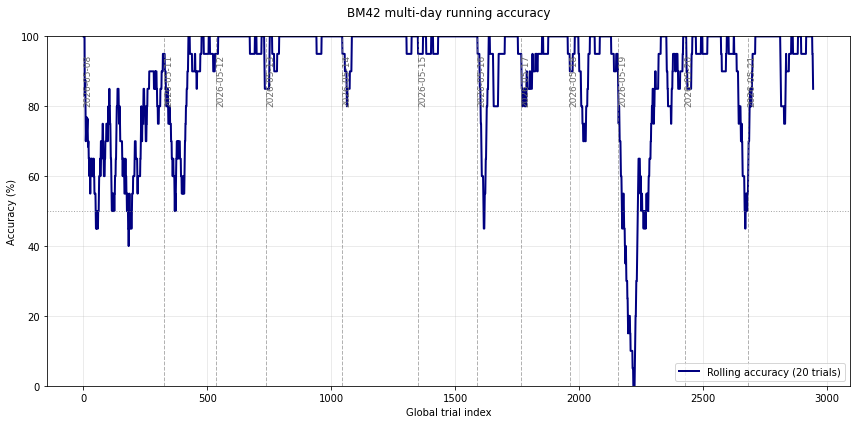

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    multi_day.trials["trial_index_global"],
    multi_day.trials["rolling_accuracy_pct"],
    color="navy",
    linewidth=2,
    label=f"Rolling accuracy ({ROLLING_WINDOW} trials)",
)
ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.set_xlabel("Global trial index")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

for transition in multi_day.day_transitions[1:]:
    ax.axvline(
        transition.first_trial_index - 0.5,
        linestyle="--",
        color="gray",
        linewidth=1,
        alpha=0.6,
    )

ymin, ymax = ax.get_ylim()
label_y = ymax - (ymax - ymin) * 0.05
for idx, transition in enumerate(multi_day.day_transitions, start=1):
    ax.text(
        transition.first_trial_index,
        label_y,
        transition.session_date.isoformat(),
        rotation=90,
        va="top",
        ha="left",
        fontsize=9,
        color="dimgray",
    )

ax.set_title(f"{ANIMAL_ID} multi-day running accuracy", pad=20)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(repo_root / "outputs" / f"{ANIMAL_ID}_multi_day_accuracy.png", dpi=300)